In [1]:
import matplotlib.pyplot as plt
plt.style.use('dslabs.mplstyle')  # Carrega as definições do estilo

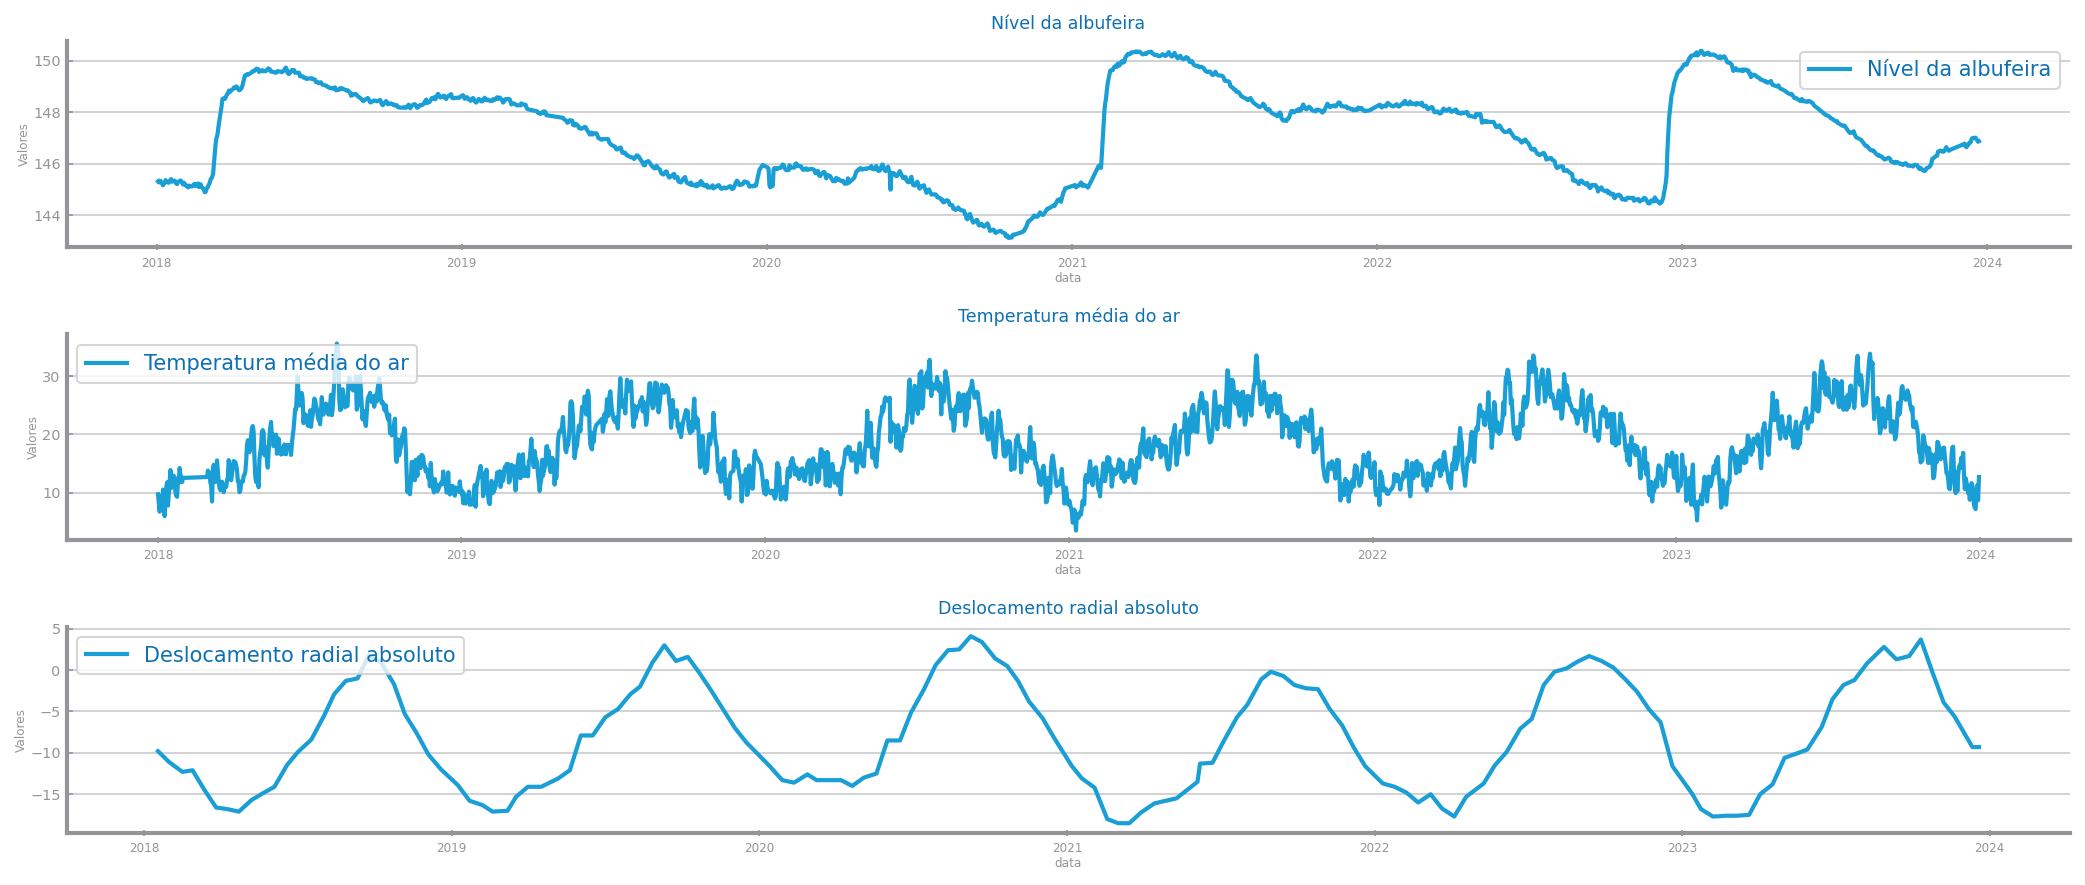

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List
from dslabs_functions import plot_ts_multivariate_chart
import matplotlib.pyplot as plt
from config import *  # Carrega as configurações do arquivo config.py

# Carregar o estilo do arquivo .mplstyle
plt.style.use('dslabs.mplstyle')  # Certifique-se de que o arquivo dslabs.mplstyle está no mesmo diretório ou forneça o caminho correto

# Carregar os dados do primeiro arquivo .xlsx
file_path1 = 'data/alqueva_nivel_tiago.xlsx'  # Caminho para o primeiro arquivo .xlsx
data1 = pd.read_excel(file_path1, parse_dates=True, index_col='data')  # Substitua 'data' pelo nome correto da coluna de data

# Carregar os dados do segundo arquivo .xlsx
file_path2 = 'data/alqueva_temp_tiago.xlsx'  # Caminho para o segundo arquivo .xlsx
data2 = pd.read_excel(file_path2, parse_dates=True, index_col='data')  # Substitua 'data' pelo nome correto da coluna de data

# Carregar os dados do terceiro arquivo .xlsx
file_path3 = 'data/alqueva_fp.xlsx'  # Caminho para o terceiro arquivo .xlsx
data3 = pd.read_excel(file_path3, parse_dates=True, index_col='data')  # Substitua 'data' pelo nome correto da coluna de data

# Selecionar uma variável de cada arquivo
# Suponhamos que você queira as variáveis 'nivel', 'var1' e 'var2'
# (substitua os nomes das variáveis conforme necessário)

data1_selected = data1[['nivel']]  # Selecione a variável 'nivel' ou qualquer outra
data2_selected = data2[['tmed']]   # Selecione a variável 'var1' ou qualquer outra
data3_selected = data3[['desl']]   # Selecione a variável 'var2' ou qualquer outra

# Função para plotar o gráfico para uma variável
def plot_single_ts(data: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    ax.plot(data.index, data.iloc[:, 0], label=title, linewidth=2)
    ax.set_xlabel(data.index.name)
    ax.set_ylabel('Valores')
    ax.set_title(title)
    ax.legend()

# Criar três gráficos separados
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 6))  # Três gráficos, um por linha

# Plotando as variáveis em gráficos separados
plot_single_ts(data1_selected, "Nível da albufeira", ax1)
plot_single_ts(data2_selected, "Temperatura média do ar", ax2)
plot_single_ts(data3_selected, "Deslocamento radial absoluto", ax3)

# Ajustar o layout
plt.tight_layout()
plt.show()

Intervalo de datas - Nível: 2018-01-02 00:00:00 a 2023-12-22 00:00:00
Intervalo de datas - Temperatura: 2018-01-01 00:00:00 a 2023-12-31 00:00:00
Intervalo de datas - Deslocamento: 2018-01-17 00:00:00 a 2023-12-19 00:00:00
Tamanho do dataset combinado: (2191, 5)
Erro: Existem valores NaN nas variáveis independentes ou dependentes.


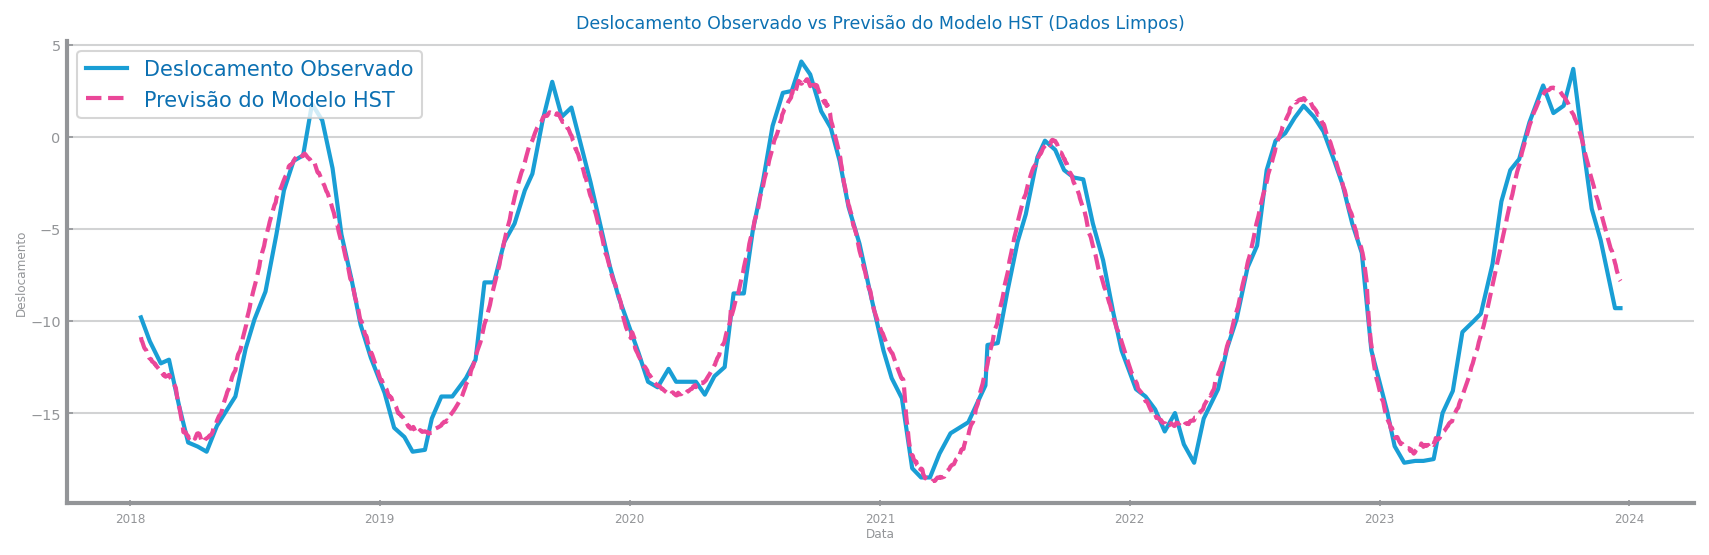

Parâmetros do Modelo HST:
a0 a a4 (coeficientes para o nível da albufeira): [ 0.00000000e+00 -6.86620484e+04  6.96161522e+02 -3.13649258e+00
  5.29818378e-03]
a5 a a8 (coeficientes para a temperatura): [-4.69821745 -5.98859844  0.74524219  0.37262036]
a9 a a10 (coeficientes para o tempo): [-0.15224453  0.00690373]


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from config import *  # Carrega as configurações do arquivo config.py

from sklearn.linear_model import LinearRegression
from datetime import datetime

# Carregar os dados
file_path1 = 'data/alqueva_nivel_tiago.xlsx'  
data1 = pd.read_excel(file_path1, parse_dates=True, index_col='data')  

file_path2 = 'data/alqueva_temp_tiago.xlsx'  
data2 = pd.read_excel(file_path2, parse_dates=True, index_col='data')  

file_path3 = 'data/alqueva_fp.xlsx'  
data3 = pd.read_excel(file_path3, parse_dates=True, index_col='data')  

# Reamostrar os três datasets para garantir que todos têm a mesma frequência diária
data1_resampled = data1.resample('D').mean()  # Reamostrar para a frequência diária
data2_resampled = data2.resample('D').mean()  # Reamostrar para a frequência diária
data3_resampled = data3.resample('D').mean()  # Reamostrar para a frequência diária

# Preencher valores ausentes com interpolação (ou usar outro método como forward-fill)
data1_resampled = data1_resampled.interpolate(method='linear')
data2_resampled = data2_resampled.interpolate(method='linear')
data3_resampled = data3_resampled.interpolate(method='linear')

# Verificar os intervalos de datas novamente após o reamostramento
print("Intervalo de datas - Nível:", data1_resampled.index.min(), "a", data1_resampled.index.max())
print("Intervalo de datas - Temperatura:", data2_resampled.index.min(), "a", data2_resampled.index.max())
print("Intervalo de datas - Deslocamento:", data3_resampled.index.min(), "a", data3_resampled.index.max())

# Alinhar os índices de tempo entre os três datasets
data_merged = pd.merge(data1_resampled, data2_resampled, left_index=True, right_index=True, how='outer')
data_merged = pd.merge(data_merged, data3_resampled, left_index=True, right_index=True, how='outer')

# Verificar o tamanho após o merge
print(f"Tamanho do dataset combinado: {data_merged.shape}")

# Verificar se o dataset tem dados
if data_merged.shape[0] == 0:
    print("Erro: O merge resultou num dataset vazio. Verifique as datas dos arquivos.")
else:
    # Agora data_merged tem as três variáveis alinhadas pelas datas
    nivel = data_merged['nivel']
    tmed = data_merged['tmed']
    desl = data_merged['desl']

    # Criar a variável de tempo t (dias desde o início)
    t = (nivel.index - nivel.index.min()).days

    # 1. Efeito Hidrostático F1(h) - Polinómio de 4ª ordem do nível
    h = nivel
    F1 = np.column_stack([h**i for i in range(5)])  # Polinómio de grau 4 (a0 + a1*h + a2*h^2 + a3*h^3 + a4*h^4)

    # 2. Efeito da Temperatura F2(s) - Funções senoides com base no ciclo anual
    s = 2 * np.pi * t / 365.25  # Para capturar o ciclo anual de temperatura
    F2 = np.column_stack([np.cos(s), np.sin(s), np.sin(2*s), np.sin(s) * np.cos(s)])

    # 3. Efeito do Tempo F3(t) - Função logarítmica e exponencial
    F3 = np.column_stack([np.log(t + 1), np.exp(t / 365.25)])  # Adicionando 1 para evitar log(0)

    # Concatenar todas as variáveis para a regressão linear
    X = np.hstack([F1, F2, F3])  # Variáveis independentes

    # Garantir que não existem NaNs em X ou y (deslocamento)
    if np.any(np.isnan(X)) or np.any(np.isnan(desl)):
        print("Erro: Existem valores NaN nas variáveis independentes ou dependentes.")
        # Remover as linhas com NaN
        data_cleaned = data_merged.dropna()  # Remove qualquer linha que tenha NaN
        nivel_cleaned = data_cleaned['nivel']
        tmed_cleaned = data_cleaned['tmed']
        desl_cleaned = data_cleaned['desl']

        # Recriar a variável de tempo t para os dados limpos
        t_cleaned = (nivel_cleaned.index - nivel_cleaned.index.min()).days

        # Repetir os cálculos com os dados limpos
        h_cleaned = nivel_cleaned
        F1_cleaned = np.column_stack([h_cleaned**i for i in range(5)])  # Polinómio de grau 4

        s_cleaned = 2 * np.pi * t_cleaned / 365.25
        F2_cleaned = np.column_stack([np.cos(s_cleaned), np.sin(s_cleaned), np.sin(2*s_cleaned), np.sin(s_cleaned) * np.cos(s_cleaned)])

        F3_cleaned = np.column_stack([np.log(t_cleaned + 1), np.exp(t_cleaned / 365.25)])

        X_cleaned = np.hstack([F1_cleaned, F2_cleaned, F3_cleaned])  # Variáveis independentes limpas

        # Ajuste da regressão linear com dados limpos
        model = LinearRegression()
        model.fit(X_cleaned, desl_cleaned)

        # Previsão do deslocamento
        desl_pred_cleaned = model.predict(X_cleaned)

        # Visualizar os resultados
        plt.figure(figsize=(14, 4))
        plt.plot(desl_cleaned.index, desl_cleaned, label="Deslocamento Observado", linewidth=2)
        #plt.plot(desl.index, desl, label="Deslocamento Observado", linestyle=':', marker='o', markersize=0.5)
        plt.plot(desl_cleaned.index, desl_pred_cleaned, label="Previsão do Modelo HST", linestyle='--', linewidth=2)
        plt.xlabel("Data")
        plt.ylabel("Deslocamento")
        plt.title("Deslocamento Observado vs Previsão do Modelo HST (Dados Limpos)")
        plt.legend()
        plt.show()

    else:
        # Ajuste da regressão linear sem NaNs (caso não haja NaNs)
        model = LinearRegression()
        model.fit(X, desl)

        # Previsão do deslocamento
        desl_pred = model.predict(X)

        # Visualizar os resultados
        plt.figure(figsize=(14, 4))
        plt.plot(desl.index, desl, label="Deslocamento Observado", linewidth=2)
        plt.plot(desl.index, desl_pred, label="Previsão do Modelo HST", linestyle='--', linewidth=2)
        plt.xlabel("Data")
        plt.ylabel("Deslocamento")
        plt.title("Deslocamento Observado vs Previsão do Modelo HST")
        plt.legend()
        plt.show()

    # Parâmetros ajustados
    print("Parâmetros do Modelo HST:")
    print("a0 a a4 (coeficientes para o nível da albufeira):", model.coef_[:5])
    print("a5 a a8 (coeficientes para a temperatura):", model.coef_[5:9])
    print("a9 a a10 (coeficientes para o tempo):", model.coef_[9:])

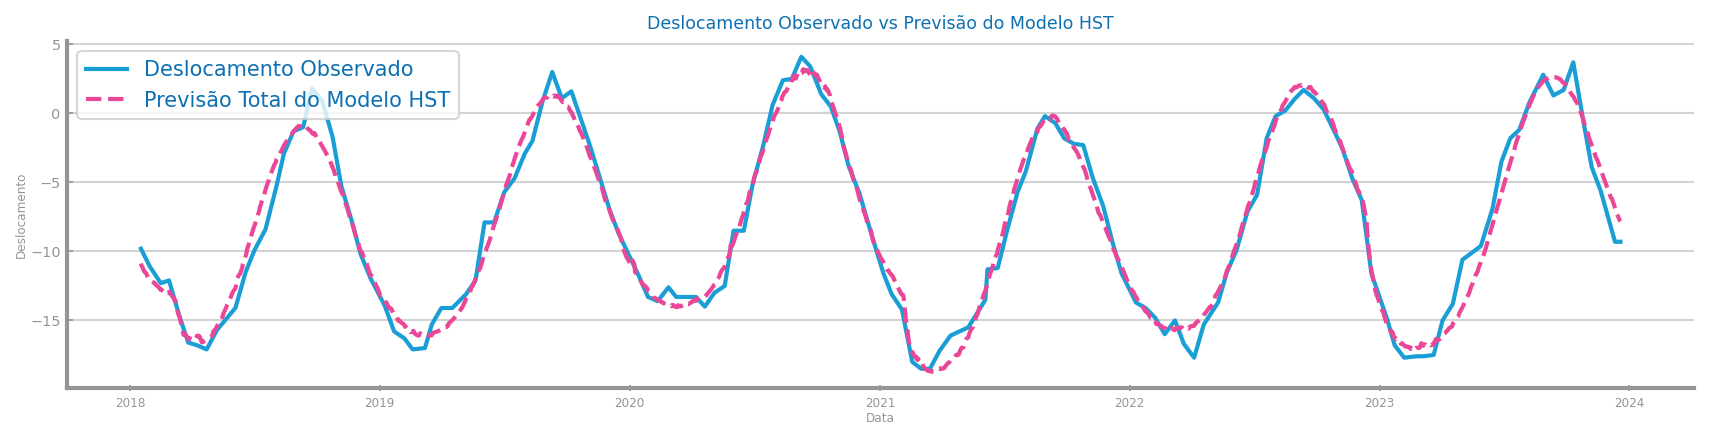

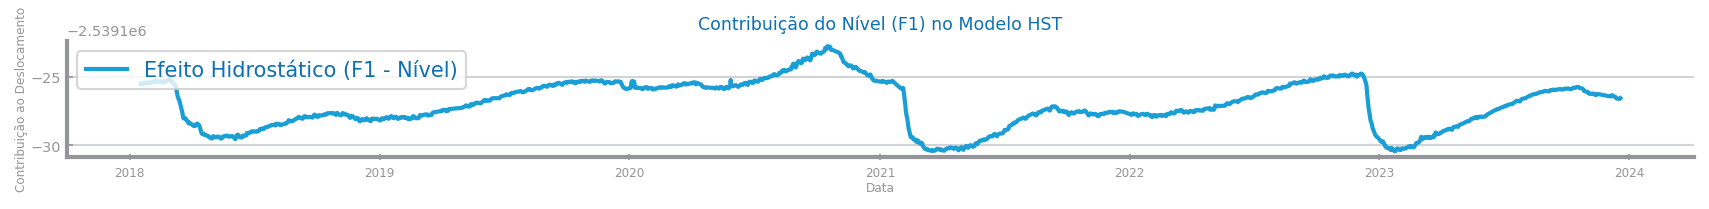

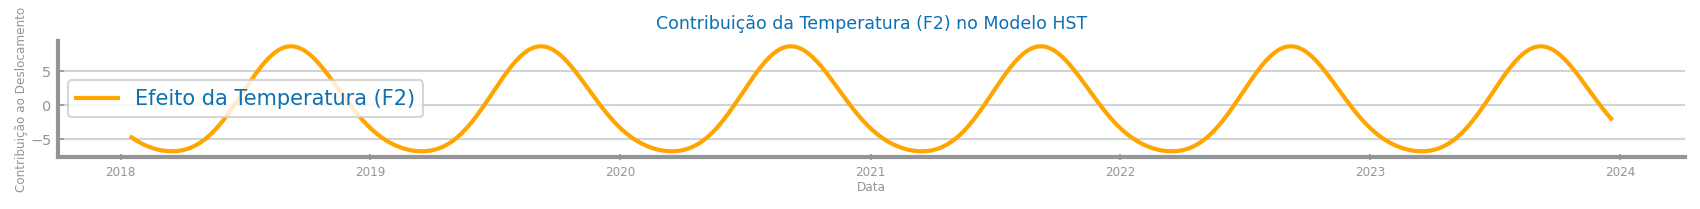

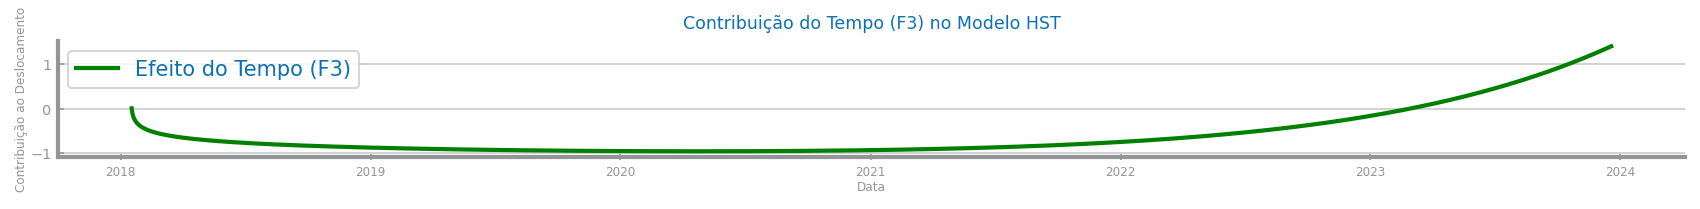

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 📌 Estilo do gráfico
plt.style.use('dslabs.mplstyle')

# Verifica se os dados já foram limpos, caso contrário, usa os originais
X_data = X_cleaned if 'X_cleaned' in locals() else X
desl_data = desl_cleaned if 'desl_cleaned' in locals() else desl

# Ajuste da regressão linear
model = LinearRegression()
model.fit(X_data, desl_data)

# Previsão do deslocamento total
desl_pred_total = model.predict(X_data)

# 📌 Contribuição individual de cada efeito
F1_pred = X_data[:, :5] @ model.coef_[:5]  # Efeito do Nível (F1)
F2_pred = X_data[:, 5:9] @ model.coef_[5:9]  # Efeito da Temperatura (F2)
F3_pred = X_data[:, 9:] @ model.coef_[9:]  # Efeito do Tempo (F3)

# 📈 Gráfico 1: Deslocamento Observado vs. Previsão Total
plt.figure(figsize=(14, 3))
plt.plot(desl_data.index, desl_data, label="Deslocamento Observado", linewidth=2)
plt.plot(desl_data.index, desl_pred_total, label="Previsão Total do Modelo HST", linestyle='--', linewidth=2)
plt.xlabel("Data")
plt.ylabel("Deslocamento")
plt.title("Deslocamento Observado vs Previsão do Modelo HST")
plt.legend()
plt.show()

# 📈 Gráfico 2: Contribuição do Nível (F1)
plt.figure(figsize=(14, 1))
plt.plot(desl_data.index, F1_pred, label="Efeito Hidrostático (F1 - Nível)", linewidth=2)
plt.xlabel("Data")
plt.ylabel("Contribuição ao Deslocamento")
plt.title("Contribuição do Nível (F1) no Modelo HST")
plt.legend()
plt.show()

# 📈 Gráfico 3: Contribuição da Temperatura (F2)
plt.figure(figsize=(14, 1))
plt.plot(desl_data.index, F2_pred, label="Efeito da Temperatura (F2)", linewidth=2, color="orange")
plt.xlabel("Data")
plt.ylabel("Contribuição ao Deslocamento")
plt.title("Contribuição da Temperatura (F2) no Modelo HST")
plt.legend()
plt.show()

# 📈 Gráfico 4: Contribuição do Tempo (F3)
plt.figure(figsize=(14, 1))
plt.plot(desl_data.index, F3_pred, label="Efeito do Tempo (F3)", linewidth=2, color="green")
plt.xlabel("Data")
plt.ylabel("Contribuição ao Deslocamento")
plt.title("Contribuição do Tempo (F3) no Modelo HST")
plt.legend()
plt.show()


In [5]:
# Exibir a matriz X
print("\nMatriz de Características (X):")
print(X)

# Visualizar as primeiras 5 linhas para inspecionar
print("\nPrimeiras 5 linhas da Matriz de Características (X):")
print(X[:5, :])

# Exibir o número de variáveis e observações
print(f"\nNúmero de variáveis (features): {X.shape[1]}")
print(f"Número de observações: {X.shape[0]}")


Matriz de Características (X):
[[ 1.00000000e+00             nan             nan ...  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00  1.45320000e+02  2.11179024e+04 ...  1.71990303e-02
   6.93147181e-01  1.00274160e+00]
 [ 1.00000000e+00  1.45280000e+02  2.11062784e+04 ...  3.43777042e-02
   1.09861229e+00  1.00549072e+00]
 ...
 [ 1.00000000e+00             nan             nan ... -6.00630826e-02
   7.69120010e+00  3.99581409e+02]
 [ 1.00000000e+00             nan             nan ... -4.29530521e-02
   7.69165682e+00  4.00676902e+02]
 [ 1.00000000e+00             nan             nan ... -2.57921834e-02
   7.69211334e+00  4.01775399e+02]]

Primeiras 5 linhas da Matriz de Características (X):
[[1.00000000e+00            nan            nan            nan
             nan 1.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.00000000e+00]
 [1.00000000e+00 1.45320000e+02 2.11179024e+04 3.06885358e+06
  4.45965802e+08 9.99852042e-01 1.72015754e-

Erro quadrático médio (MSE) - Treino: 1.1986
Erro quadrático médio (MSE) - Teste: 4.2678


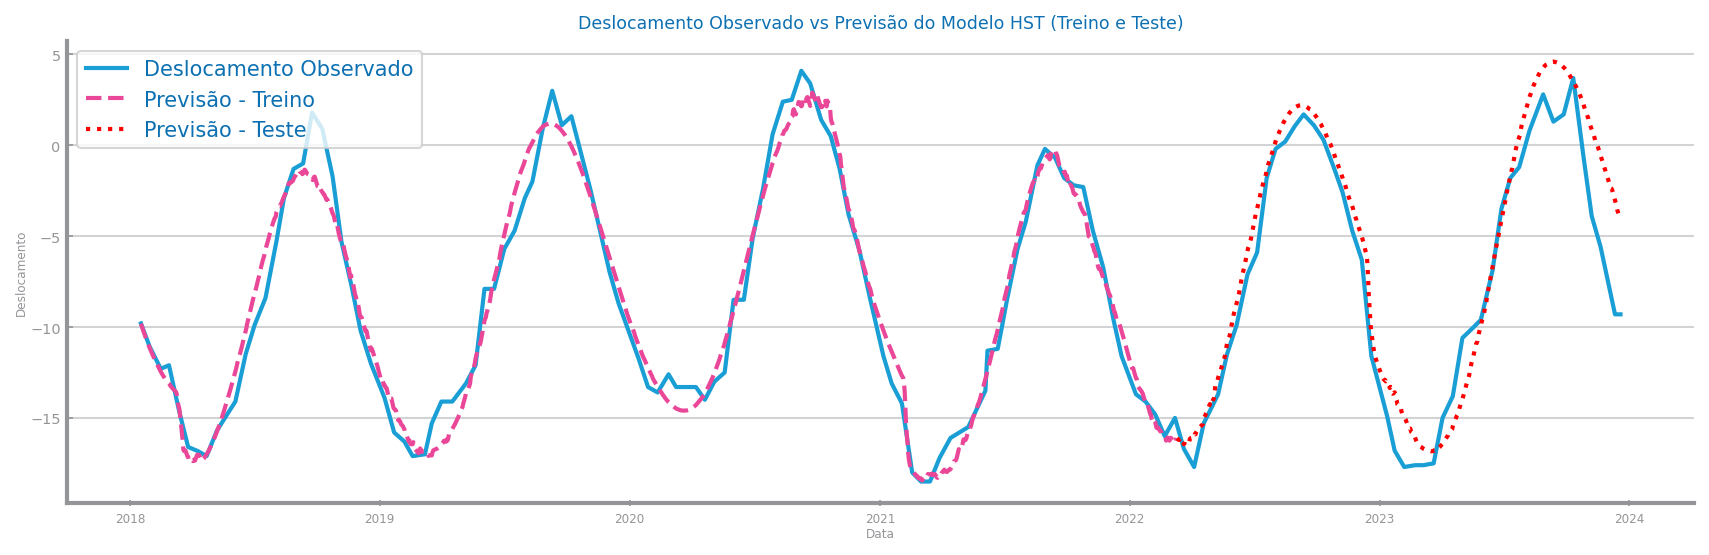

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Remover qualquer linha com valores NaN em X ou y
mask = ~np.isnan(X).any(axis=1) & ~np.isnan(desl)
X_clean = X[mask]
desl_clean = desl[mask]

# Definir proporção de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X_clean, desl_clean, test_size=0.3, shuffle=False)

# Ajustar a regressão linear com os dados de treino
model = LinearRegression()
model.fit(X_train, y_train)

# Fazer previsões
y_train_pred = model.predict(X_train)  # Previsão para treino
y_test_pred = model.predict(X_test)    # Previsão para teste

# Calcular erro para treino e teste
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Erro quadrático médio (MSE) - Treino: {train_mse:.4f}")
print(f"Erro quadrático médio (MSE) - Teste: {test_mse:.4f}")

# 📈 Visualizar os resultados
plt.figure(figsize=(14, 4))
plt.plot(desl_clean.index, desl_clean, label="Deslocamento Observado", linestyle='-', linewidth=2)
plt.plot(y_train.index, y_train_pred, label="Previsão - Treino", linestyle='--', linewidth=2)
plt.plot(y_test.index, y_test_pred, label="Previsão - Teste", linestyle=':', linewidth=2, color='red')

plt.xlabel("Data")
plt.ylabel("Deslocamento")
plt.title("Deslocamento Observado vs Previsão do Modelo HST (Treino e Teste)")
plt.legend()
plt.show()


Erro quadrático médio (MSE) - Treino: 1.1986
Erro quadrático médio (MSE) - Teste: 4.2678


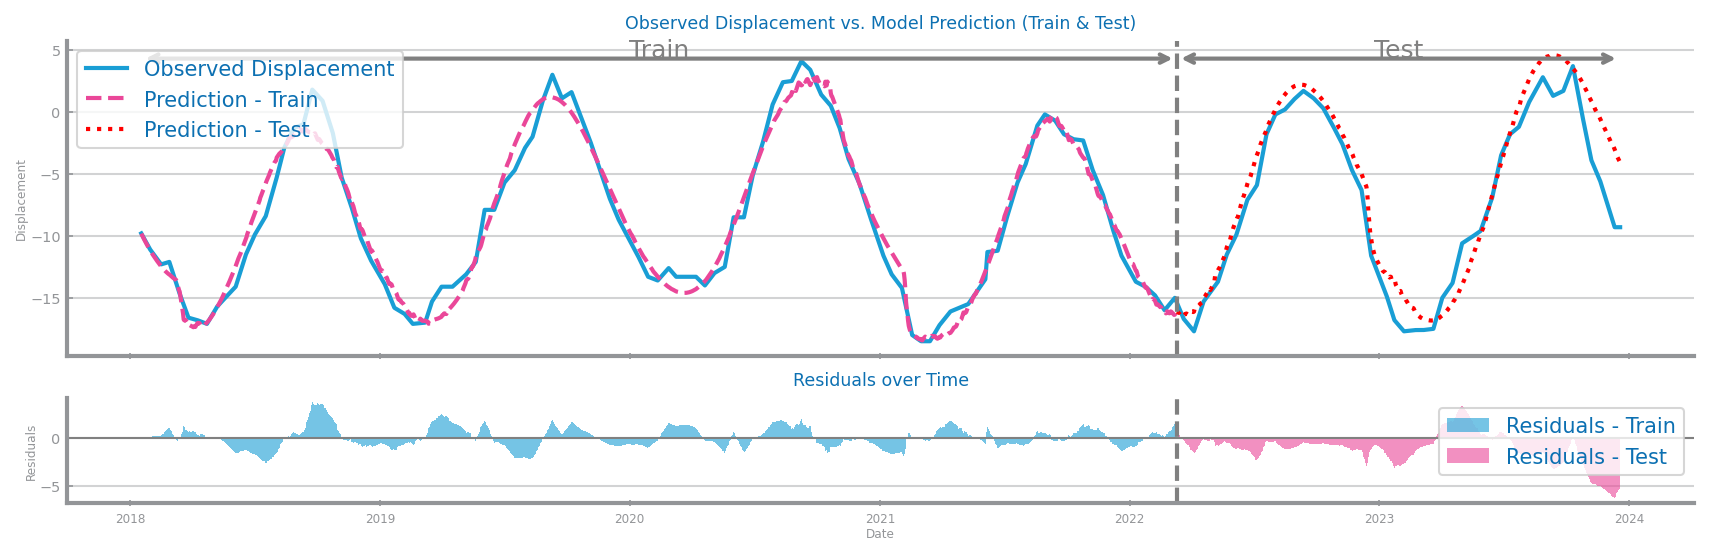

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Remover qualquer linha com valores NaN em X ou y
mask = ~np.isnan(X).any(axis=1) & ~np.isnan(desl)
X_clean = X[mask]
desl_clean = desl[mask]

# Definir proporção de treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X_clean, desl_clean, test_size=0.3, shuffle=False)

# Ajustar a regressão linear com os dados de treino
model = LinearRegression()
model.fit(X_train, y_train)

# Fazer previsões
y_train_pred = model.predict(X_train)  # Previsão para treino
y_test_pred = model.predict(X_test)    # Previsão para teste

# Calcular os resíduos
residuos_treino = y_train - y_train_pred
residuos_teste = y_test - y_test_pred

# Encontrar a data onde começa o teste
split_date = y_test.index.min()

# Calcular erro para treino e teste
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Erro quadrático médio (MSE) - Treino: {train_mse:.4f}")
print(f"Erro quadrático médio (MSE) - Teste: {test_mse:.4f}")

# 📈 Criar gráficos
fig, axs = plt.subplots(2, 1, figsize=(14, 4), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Gráfico 1: Observado vs. Previsão
axs[0].plot(desl_clean.index, desl_clean, label="Observed Displacement", linestyle='-', linewidth=2)
axs[0].plot(y_train.index, y_train_pred, label="Prediction - Train", linestyle='--', linewidth=2)
axs[0].plot(y_test.index, y_test_pred, label="Prediction - Test", linestyle=':', linewidth=2, color='red')

# Linha vertical separando treino e teste
axs[0].axvline(split_date, color='grey', linestyle='--', linewidth=2)

# Adicionar seta horizontal indicando treino e teste
axs[0].annotate("", xy=(y_train.index[0], max(desl_clean) * 1.05), xytext=(split_date, max(desl_clean) * 1.05),
                arrowprops=dict(arrowstyle="<->", color="grey", lw=2))
axs[0].annotate("", xy=(split_date, max(desl_clean) * 1.05), xytext=(y_test.index[-1], max(desl_clean) * 1.05),
                arrowprops=dict(arrowstyle="<->", color="grey", lw=2))

# Adicionar texto indicando as regiões
axs[0].text(y_train.index[int(len(y_train) * 0.5)], max(desl_clean) * 1.08, "Train", fontsize=12, color='grey', ha='center')
axs[0].text(y_test.index[int(len(y_test) * 0.5)], max(desl_clean) * 1.08, "Test", fontsize=12, color='grey', ha='center')

axs[0].set_ylabel("Displacement")
axs[0].set_title("Observed Displacement vs. Model Prediction (Train & Test)")
axs[0].legend()

# Gráfico 2: Resíduos como barras
axs[1].bar(y_train.index, residuos_treino, width=1, label="Residuals - Train",  alpha=0.6)
axs[1].bar(y_test.index, residuos_teste, width=1, label="Residuals - Test",  alpha=0.6)

# Linha preta horizontal em y=0 para referência
axs[1].axhline(0, color='grey', linestyle='-', linewidth=1)

# Linha vertical separando treino e teste
axs[1].axvline(split_date, color='grey', linestyle='--', linewidth=2)

axs[1].set_xlabel("Date")
axs[1].set_ylabel("Residuals")
axs[1].set_title("Residuals over Time")
axs[1].legend()

plt.show()



In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calcular métricas para treino
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))  # Corrigido
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Calcular métricas para teste
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))  # Corrigido
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# Exibir resultados
print("📊 **Métricas de desempenho do modelo**")
print(f"🔹 R² (Treino): {r2_train:.4f} | R² (Teste): {r2_test:.4f}")
print(f"🔹 MAE (Treino): {mae_train:.4f} | MAE (Teste): {mae_test:.4f}")
print(f"🔹 RMSE (Treino): {rmse_train:.4f} | RMSE (Teste): {rmse_test:.4f}")
print(f"🔹 MAPE (Treino): {mape_train:.2f}% | MAPE (Teste): {mape_test:.2f}%")

📊 **Métricas de desempenho do modelo**
🔹 R² (Treino): 0.9691 | R² (Teste): 0.9094
🔹 MAE (Treino): 0.8682 | MAE (Teste): 1.5730
🔹 RMSE (Treino): 1.0948 | RMSE (Teste): 2.0659
🔹 MAPE (Treino): 54.84% | MAPE (Teste): inf%


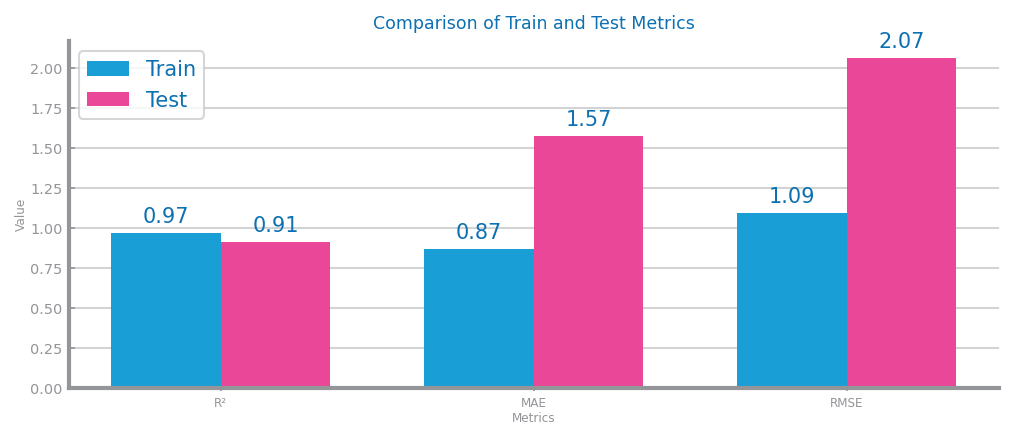

In [9]:
import matplotlib.pyplot as plt

# Aplicar o estilo personalizado
plt.style.use('dslabs.mplstyle')

# Criar listas com os valores das métricas (sem o MAPE)
metricas = ["R²", "MAE", "RMSE"]
valores_treino = [r2_train, mae_train, rmse_train]
valores_teste = [r2_test, mae_test, rmse_test]

# Criar gráfico de barras
fig, ax = plt.subplots(figsize=(8, 3))
x = range(len(metricas))  # Posições das métricas no eixo X
width = 0.35  # Largura das barras

bars1 = ax.bar([i - width/2 for i in x], valores_treino, width, label="Train")
bars2 = ax.bar([i + width/2 for i in x], valores_teste, width, label="Test")

# Adicionar rótulos e título
ax.set_xlabel("Metrics")
ax.set_ylabel("Value")
ax.set_title("Comparison of Train and Test Metrics")
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()

# Exibir valores nas barras
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # Pequeno deslocamento do texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Mostrar gráfico
plt.show()